# Capstone 3 — Step 3: Exploratory Data Analysis
**Predicting Churn and Customer Lifetime Value in a Non-Contractual E-Commerce Setting**

**Student:** Justin Ali · Springboard Data Science Career Track  
**Dataset:** UCI Online Retail II · Customer Feature Table from `01_data_wrangling.ipynb`  
**Notebook:** `02_eda.ipynb`

---

## Purpose

This notebook performs a structured exploratory data analysis (EDA) on the cleansed customer-level feature table produced in the wrangling step:

1. **Business workflow understanding** — Data flow diagram and user story mapping for this project
2. **Feature-level exploration** — Histograms, descriptive stats, and outlier checks for all 20 features
3. **Bivariate analysis** — How each feature relates to the churn target (`repurchase_90d`)
4. **Correlation analysis** — Pearson correlation matrix with significance testing
5. **ML model selection rationale** — Which model types fit this business problem and why
6. **Feature selection decisions** — Which features to carry forward into modeling and why
7. **Evaluation framework** — How we will measure model effectiveness in business terms

> **Relationship to the wrangling notebook:** `01_data_wrangling.ipynb` already produced an overview revenue distribution, monthly trend, and cohort retention heatmap as sanity checks. This notebook goes substantially deeper — systematic per-feature analysis, statistical relationship testing, and business-framed conclusions.

---
## 0. Setup & Data Load

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, pearsonr
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = '../data/processed/'
FIG_DIR       = '../data/processed/'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
cust = pd.read_csv(os.path.join(PROCESSED_DIR, 'customer_features.csv'))
txn  = pd.read_csv(os.path.join(PROCESSED_DIR, 'transactions_clean.csv'),
                   parse_dates=['invoicedate'])

print(f'Customer feature table : {cust.shape[0]:,} rows × {cust.shape[1]} cols')
print(f'Transaction log        : {txn.shape[0]:,} rows × {txn.shape[1]} cols')
print()
print('Feature table columns:')
print(list(cust.columns))

Customer feature table : 4,398 rows × 23 cols
Transaction log        : 802,932 rows × 13 cols

Feature table columns:
['customer_id', 'frequency', 'monetary_total', 'country', 'recency_days', 'monetary_avg_basket', 'tenure_days', 'n_unique_products', 'n_unique_categories_proxy', 'basket_size_avg', 'basket_size_std', 'n_cancel_invoices', 'return_rate', 'weekend_share', 'interpurchase_time_mean', 'interpurchase_time_max', 'last_gap_days', 'last_vs_avg_gap_ratio', 'is_uk', 'avg_unit_price', 'price_tier', 'repurchase_90d', 'repurchase_180d']


---
## 1. Business Workflow Understanding

### 1.1 Existing Business Workflow (without data solution)

```
┌─────────────────────────────────────────────────────────────────────┐
│                  EXISTING RETENTION WORKFLOW                        │
│                                                                     │
│  Customers transact  →  CRM stores history  →  Marketing team      │
│  on e-commerce site        (raw orders)         reviews manually   │
│                                                        │            │
│                                              Sends blanket offers  │
│                                              to "inactive" list    │
│                                              (no targeting logic)  │
│                                                        │            │
│                                              Budget wasted on      │
│                                              already-loyal or      │
│                                              truly-gone customers  │
└─────────────────────────────────────────────────────────────────────┘
```

**Problem:** Without a churn probability or CLV estimate, the marketing team cannot distinguish between:
- Customers who are simply *between purchases* (normal for infrequent buyers)
- Customers who have genuinely *disengaged*
- High-value vs. low-value customers within either group

---

### 1.2 Augmented Workflow (with data solution)

```
┌─────────────────────────────────────────────────────────────────────┐
│              DATA-AUGMENTED RETENTION WORKFLOW                      │
│                                                                     │
│  Transaction DB  →  Feature pipeline  →  Churn model  →  CLV model │
│   (raw orders)      (RFM, tenure,         (XGBoost /    (BG/NBD +  │
│                      behavior,             LightGBM)    Gamma-Gamma)│
│                      temporal)                │              │      │
│                                              ▼              ▼      │
│                                       Churn prob   Expected CLV    │
│                                              │              │      │
│                                              └──── 2×2 ─────┘      │
│                                               Segmentation matrix  │
│                                                      │             │
│                                         Streamlit dashboard:       │
│                                         per-customer score +       │
│                                         SHAP explanation +         │
│                                         recommended action +       │
│                                         expected ROI               │
└─────────────────────────────────────────────────────────────────────┘
```

### 1.3 User Story

> *As a retention marketing manager, I want to see a ranked list of customers by (churn risk × expected CLV), so that I can allocate retention budget to the highest-leverage segment and quantify the expected revenue impact of my campaign.*

**Acceptance criteria:**
- Each customer has a calibrated churn probability (0–1)
- Each customer has a predicted 90-day and 180-day CLV estimate
- The dashboard explains *why* a customer is flagged (SHAP)
- A sensitivity table shows expected ROI at different offer costs and uplift assumptions

---
## 2. Univariate Feature Analysis

We examine every feature individually — distribution shape, central tendency, spread, and outlier presence. This tells us which features need transformation before modeling and which carry the most signal variance.

In [2]:
# ── Descriptive statistics for all numeric features ───────────────────────────
NUMERIC_FEATURES = [
    'recency_days', 'frequency', 'monetary_total', 'monetary_avg_basket',
    'tenure_days', 'n_unique_products', 'n_unique_categories_proxy',
    'basket_size_avg', 'basket_size_std', 'n_cancel_invoices', 'return_rate',
    'weekend_share', 'interpurchase_time_mean', 'interpurchase_time_max',
    'last_gap_days', 'last_vs_avg_gap_ratio', 'avg_unit_price'
]

CATEGORICAL_FEATURES = ['price_tier', 'is_uk']
TARGET = 'repurchase_90d'

stats_df = cust[NUMERIC_FEATURES].describe().T
stats_df['skewness'] = cust[NUMERIC_FEATURES].skew()
stats_df['kurtosis'] = cust[NUMERIC_FEATURES].kurt()
stats_df['null_count'] = cust[NUMERIC_FEATURES].isnull().sum()

print('=== Descriptive Statistics for All Numeric Features ===')
print(stats_df[['count','mean','std','min','25%','50%','75%','max',
                'skewness','kurtosis','null_count']].to_string())

=== Descriptive Statistics for All Numeric Features ===
                              count      mean       std    min      25%      50%       75%         max  skewness  kurtosis  null_count
recency_days              4398.0000  125.1169  105.0007 0.0000  55.0000  90.0000  168.0000    426.0000    1.1310    0.4374           0
frequency                 4398.0000    4.6880    8.5649 1.0000   1.0000   2.0000    5.0000    198.0000    9.8902  149.6722           0
monetary_total            4398.0000 2231.9852 9732.6552 2.9500 312.6575 740.2050 1846.1425 376998.9600   23.4458  731.6381           0
monetary_avg_basket       4398.0000  386.9527  519.7376 2.9500 185.2037 293.7500  430.6208  11880.8400   11.6169  207.0051           0
tenure_days               4398.0000  146.1812  144.5458 0.0000   0.0000 113.0000  276.0000    425.0000    0.4414   -1.3005           0
n_unique_products         4398.0000   66.1630   89.4043 1.0000  17.0000  39.0000   82.0000   1776.0000    5.9619   73.4854           0

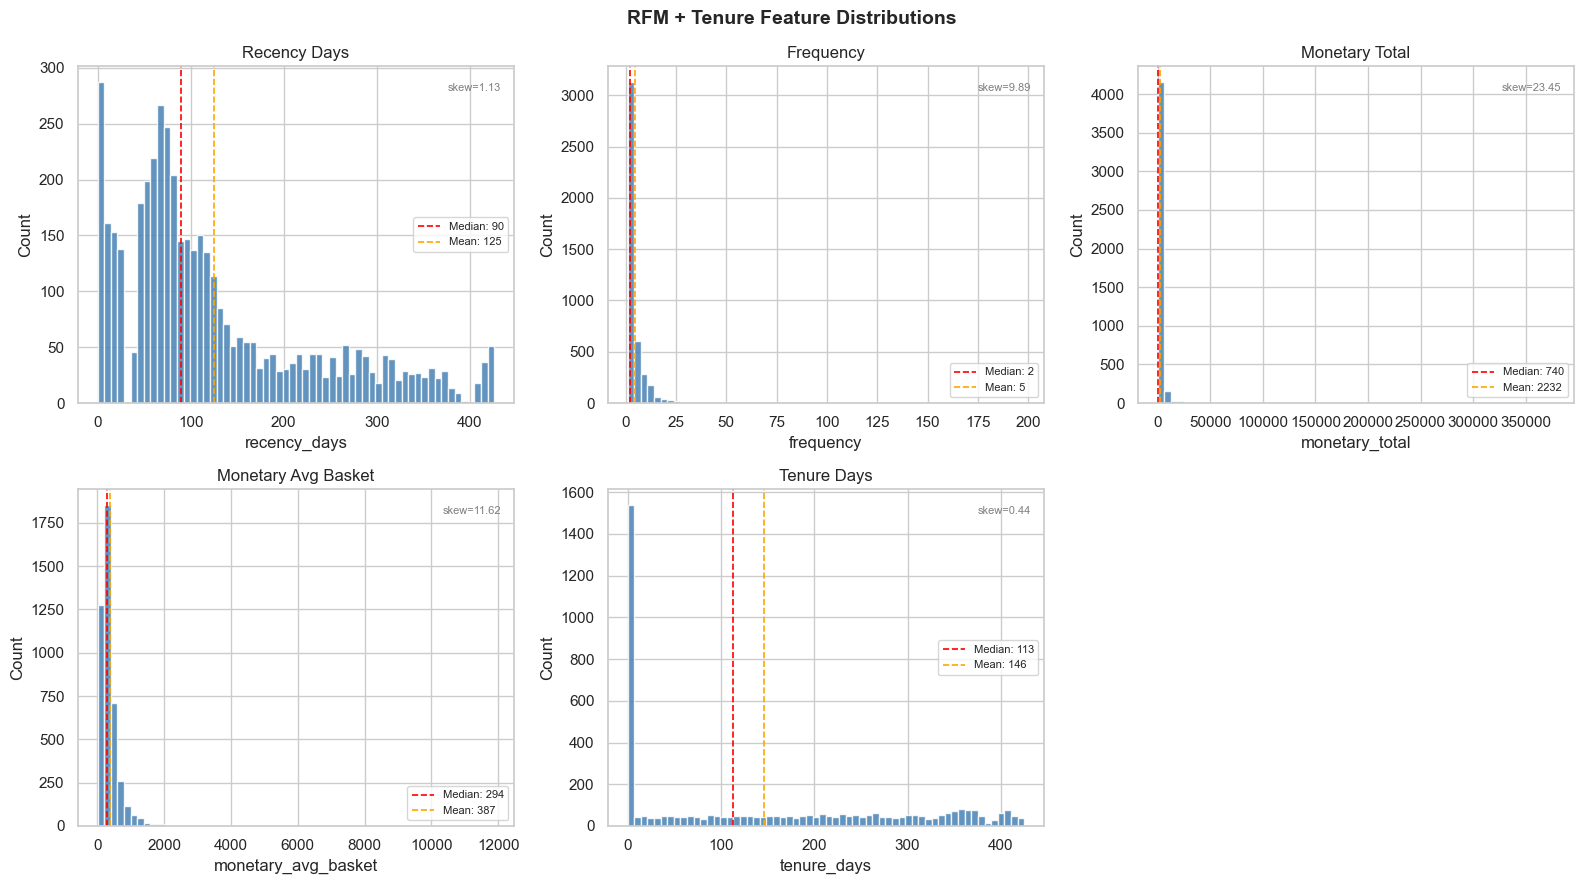


Key observations:
  • frequency and monetary_total are highly right-skewed (long tail of high-value customers)
  • recency_days is roughly uniform — customers are spread across the calibration window
  • Log-transformation will be warranted for frequency, monetary, and tenure in modeling


In [3]:
# ── Histograms: RFM + Tenure features ────────────────────────────────────────
rfm_features = ['recency_days', 'frequency', 'monetary_total',
                 'monetary_avg_basket', 'tenure_days']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(rfm_features):
    ax = axes[i]
    data = cust[feat].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red',    linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.0f}')
    ax.axvline(data.mean(),   color='orange', linestyle='--', linewidth=1.2,
               label=f'Mean: {data.mean():.0f}')
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    skew = data.skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

axes[-1].set_visible(False)
plt.suptitle('RFM + Tenure Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_hist_rfm.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  • frequency and monetary_total are highly right-skewed (long tail of high-value customers)')
print('  • recency_days is roughly uniform — customers are spread across the calibration window')
print('  • Log-transformation will be warranted for frequency, monetary, and tenure in modeling')

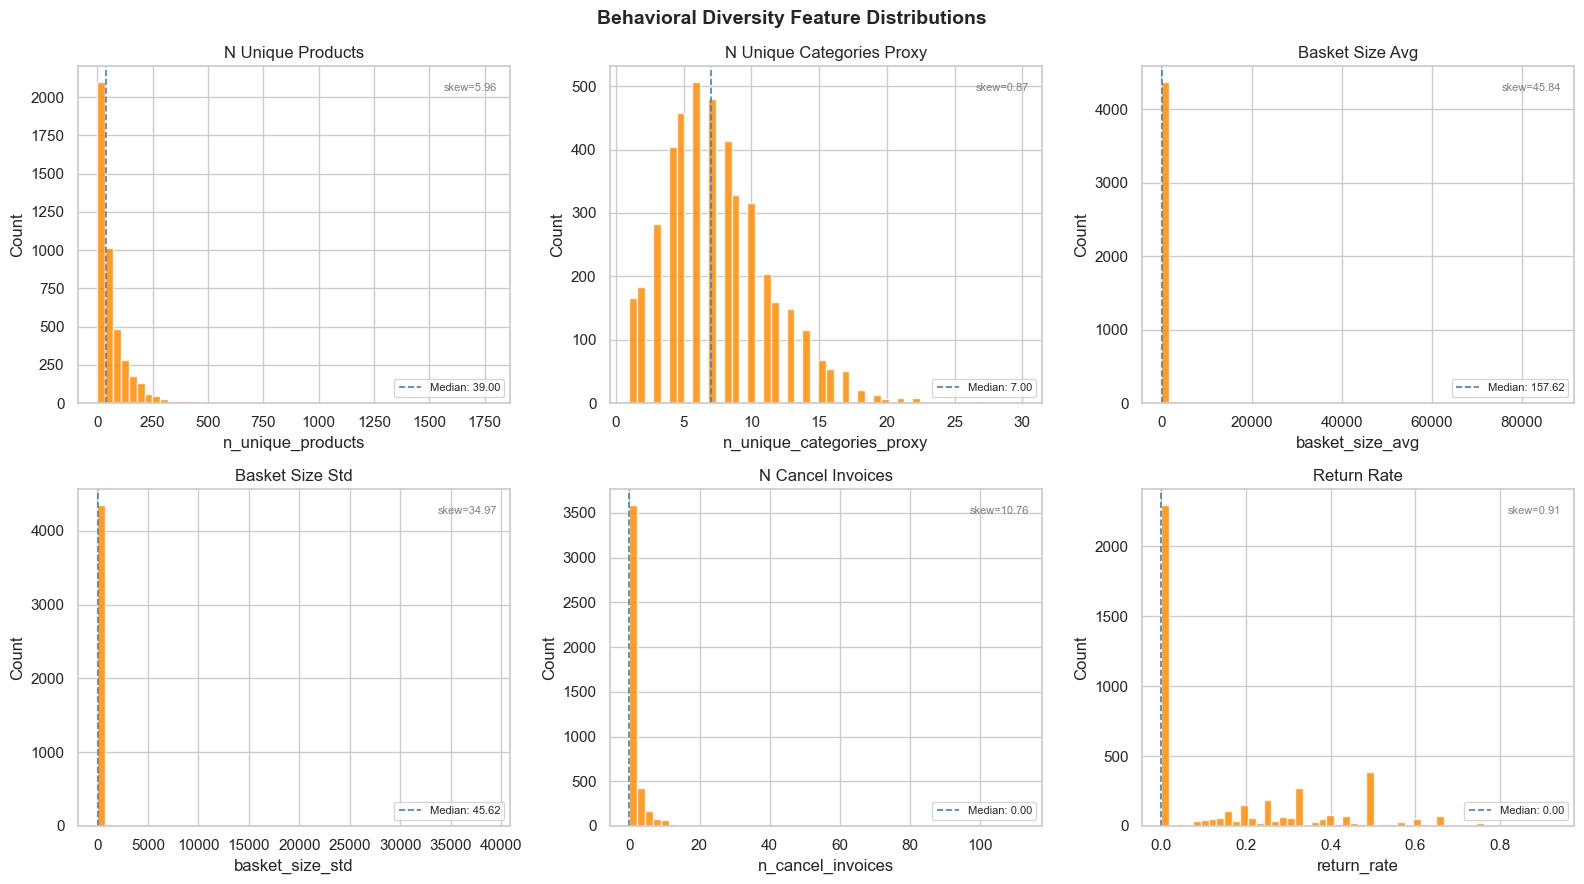


Key observations:
  • n_unique_products is right-skewed; most customers buy from a narrow range
  • return_rate clusters near 0 for most customers; heavy returners are a small tail
  • n_cancel_invoices is zero-inflated — most customers have no cancellations


In [4]:
# ── Histograms: Behavioral Diversity features ──────────────────────────────────
behav_features = ['n_unique_products', 'n_unique_categories_proxy',
                   'basket_size_avg', 'basket_size_std',
                   'n_cancel_invoices', 'return_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(behav_features):
    ax = axes[i]
    data = cust[feat].dropna()
    ax.hist(data, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='steelblue', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.2f}')
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    skew = data.skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.suptitle('Behavioral Diversity Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_hist_behavioral.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  • n_unique_products is right-skewed; most customers buy from a narrow range')
print('  • return_rate clusters near 0 for most customers; heavy returners are a small tail')
print('  • n_cancel_invoices is zero-inflated — most customers have no cancellations')

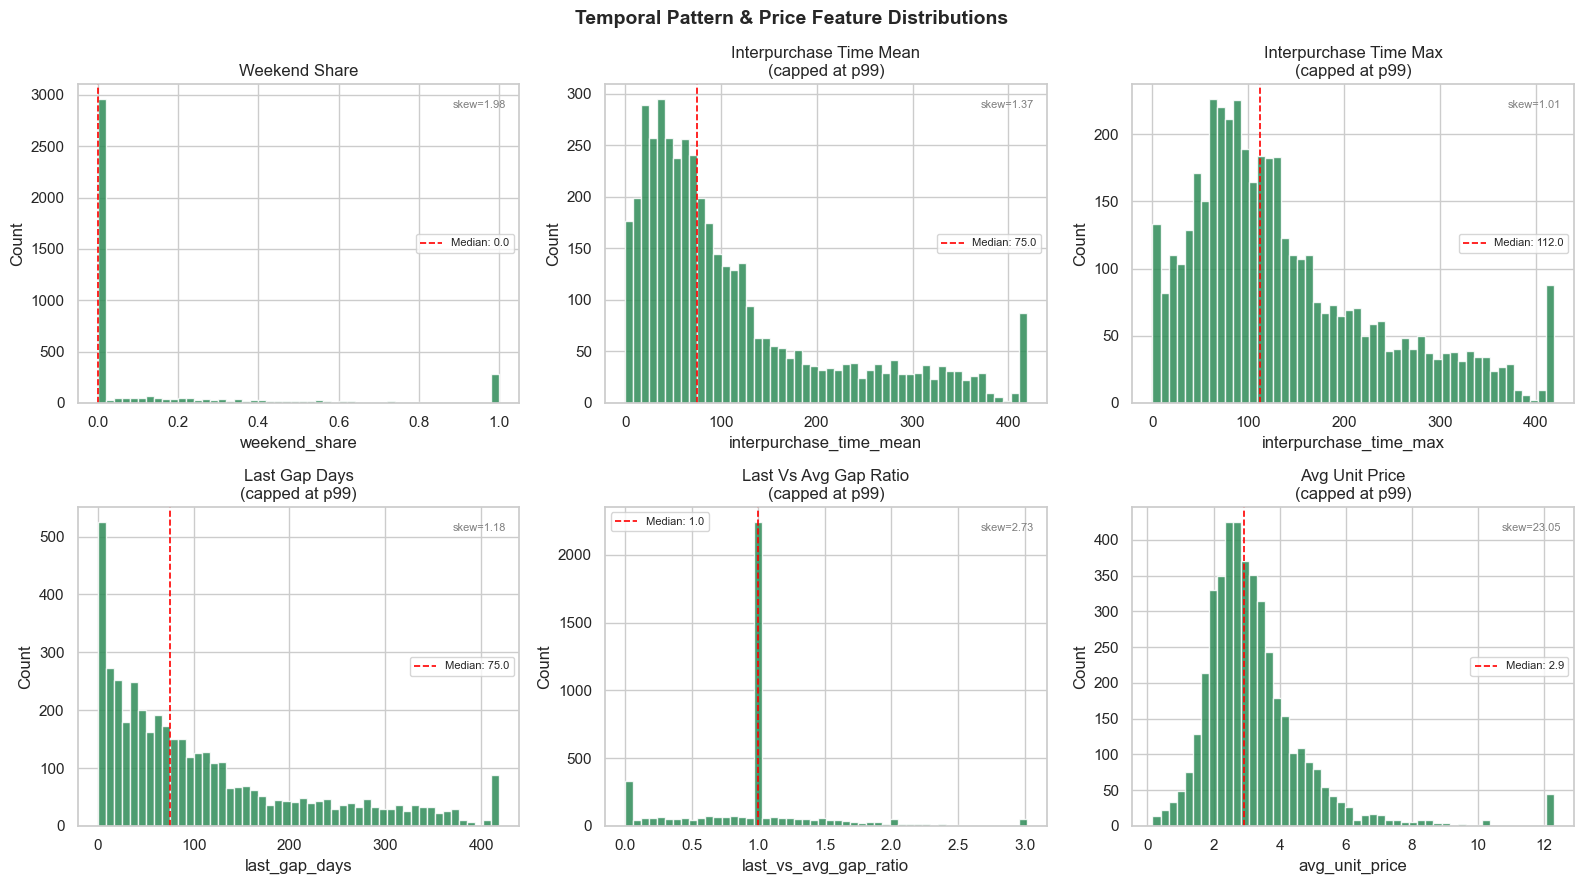


Key observations:
  • weekend_share clusters near 0 — this retailer is predominantly weekday-driven
  • interpurchase_time_mean is right-skewed; many customers buy infrequently
  • last_vs_avg_gap_ratio > 1 for a substantial fraction — signals potential drift


In [5]:
# ── Histograms: Temporal Pattern features ────────────────────────────────────
temporal_features = ['weekend_share', 'interpurchase_time_mean',
                      'interpurchase_time_max', 'last_gap_days',
                      'last_vs_avg_gap_ratio', 'avg_unit_price']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(temporal_features):
    ax = axes[i]
    data = cust[feat].dropna()
    # Cap extreme outliers for visualization only
    p99 = data.quantile(0.99)
    data_plot = data.clip(upper=p99)
    ax.hist(data_plot, bins=50, color='seagreen', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f}')
    ax.set_title(feat.replace('_', ' ').title() +
                 ('\n(capped at p99)' if data.max() > p99 else ''))
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    skew = data.skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.suptitle('Temporal Pattern & Price Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_hist_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('  • weekend_share clusters near 0 — this retailer is predominantly weekday-driven')
print('  • interpurchase_time_mean is right-skewed; many customers buy infrequently')
print('  • last_vs_avg_gap_ratio > 1 for a substantial fraction — signals potential drift')

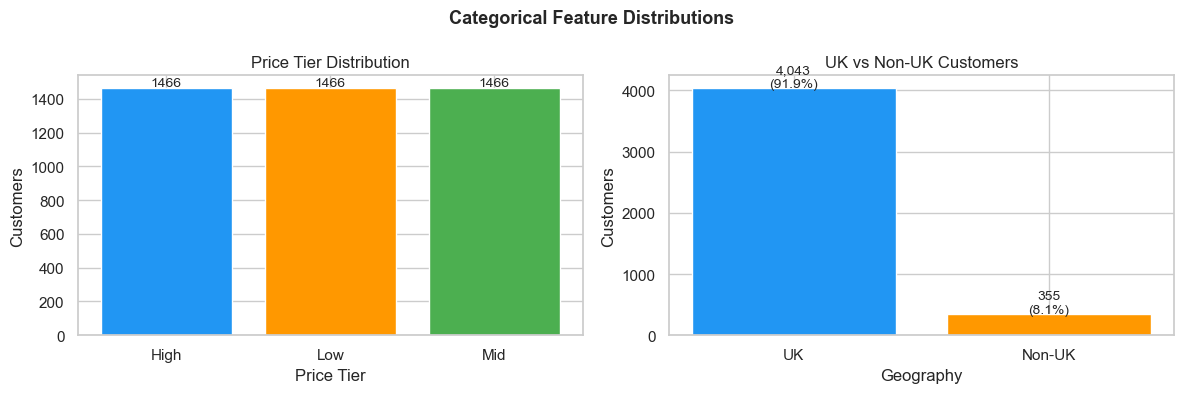

In [6]:
# ── Categorical features: price_tier and is_uk ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price tier
pt_counts = cust['price_tier'].value_counts()
axes[0].bar(pt_counts.index, pt_counts.values, color=['#2196F3','#FF9800','#4CAF50'],
            edgecolor='white')
for j, (idx, val) in enumerate(pt_counts.items()):
    axes[0].text(j, val + 10, str(val), ha='center', fontsize=10)
axes[0].set_title('Price Tier Distribution')
axes[0].set_xlabel('Price Tier')
axes[0].set_ylabel('Customers')

# UK vs non-UK
uk_counts = cust['is_uk'].map({1: 'UK', 0: 'Non-UK'}).value_counts()
axes[1].bar(uk_counts.index, uk_counts.values, color=['#2196F3','#FF9800'],
            edgecolor='white')
for j, (idx, val) in enumerate(uk_counts.items()):
    axes[1].text(j, val + 10, f'{val:,}\n({val/len(cust)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[1].set_title('UK vs Non-UK Customers')
axes[1].set_xlabel('Geography')
axes[1].set_ylabel('Customers')

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_categorical.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Bivariate Analysis — Features vs. Churn Target

We compare the distribution of each feature for customers who **repurchased within 90 days** vs. those who **did not** (churned). Box plots with individual data points overlaid make median differences and spread visible simultaneously.

This is the most important section for feature selection: features where the two groups are well-separated carry predictive signal.

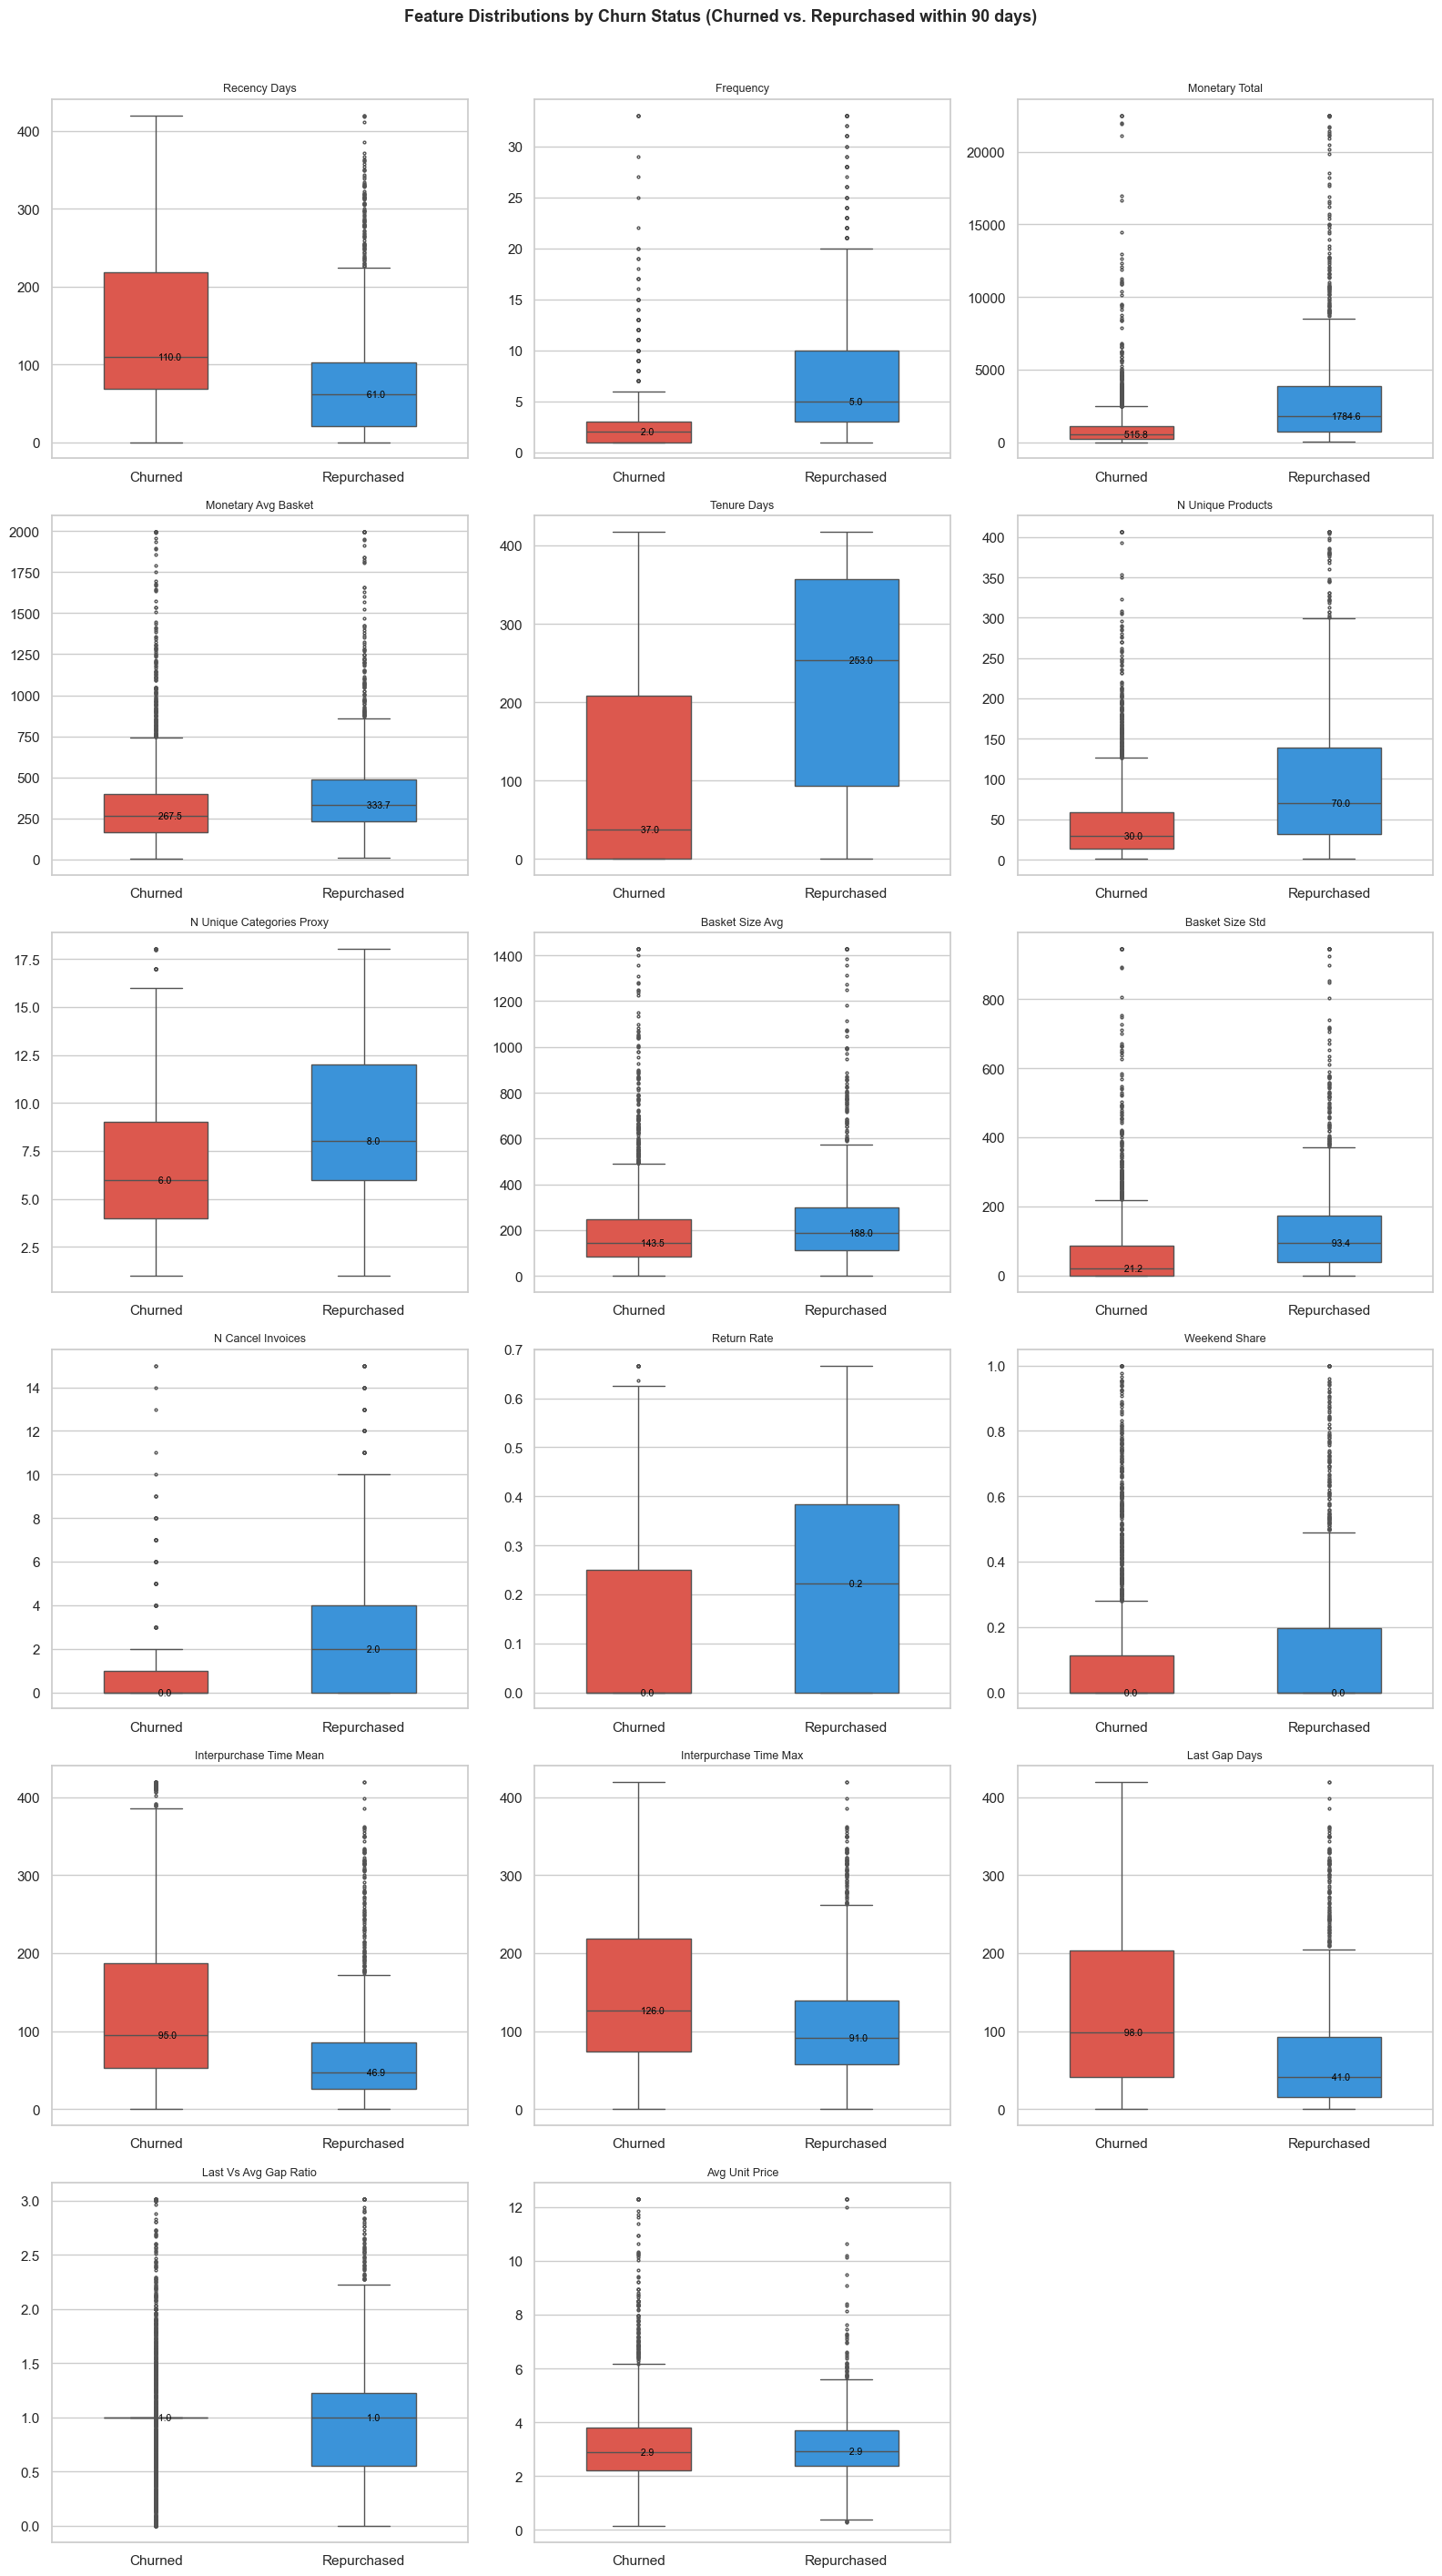

In [7]:
# ── Boxplots: each numeric feature by repurchase_90d ─────────────────────────
cust['churn_label'] = cust['repurchase_90d'].map({1: 'Repurchased', 0: 'Churned'})

fig, axes = plt.subplots(6, 3, figsize=(16, 28))
axes = axes.flatten()

palette = {'Repurchased': '#2196F3', 'Churned': '#F44336'}

for i, feat in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    data = cust[[feat, 'churn_label']].dropna()
    # Cap at p99 for visual clarity
    p99 = data[feat].quantile(0.99)
    data[feat] = data[feat].clip(upper=p99)

    sns.boxplot(data=data, x='churn_label', y=feat, palette=palette,
                order=['Churned', 'Repurchased'], ax=ax,
                width=0.5, fliersize=2)

    # Compute and annotate group medians
    for j, label in enumerate(['Churned', 'Repurchased']):
        med = data[data['churn_label'] == label][feat].median()
        ax.text(j, med, f' {med:.1f}', va='center', fontsize=7.5, color='black')

    ax.set_title(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Hide unused subplots
for k in range(len(NUMERIC_FEATURES), len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Feature Distributions by Churn Status (Churned vs. Repurchased within 90 days)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_bivariate_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Bivariate summary table ───────────────────────────────────────────────────
print('=== Median Values: Churned vs. Repurchased (90-day window) ===')
summary_rows = []
for feat in NUMERIC_FEATURES:
    churned  = cust[cust['repurchase_90d'] == 0][feat].dropna()
    retained = cust[cust['repurchase_90d'] == 1][feat].dropna()
    # Mann-Whitney U test (non-parametric, appropriate for skewed distributions)
    stat, p = stats.mannwhitneyu(churned, retained, alternative='two-sided')
    summary_rows.append({
        'Feature': feat,
        'Median (Churned)': churned.median(),
        'Median (Retained)': retained.median(),
        'Difference': retained.median() - churned.median(),
        'Mann-Whitney p': p,
        'Significant': '✓' if p < 0.05 else '✗'
    })

summary_df = pd.DataFrame(summary_rows).set_index('Feature')
print(summary_df.to_string())

=== Median Values: Churned vs. Repurchased (90-day window) ===
                           Median (Churned)  Median (Retained)  Difference  Mann-Whitney p Significant
Feature                                                                                               
recency_days                       110.0000            61.0000    -49.0000          0.0000           ✓
frequency                            2.0000             5.0000      3.0000          0.0000           ✓
monetary_total                     515.7800          1784.5700   1268.7900          0.0000           ✓
monetary_avg_basket                267.4950           333.6956     66.2006          0.0000           ✓
tenure_days                         37.0000           253.0000    216.0000          0.0000           ✓
n_unique_products                   30.0000            70.0000     40.0000          0.0000           ✓
n_unique_categories_proxy            6.0000             8.0000      2.0000          0.0000           ✓
basket_siz

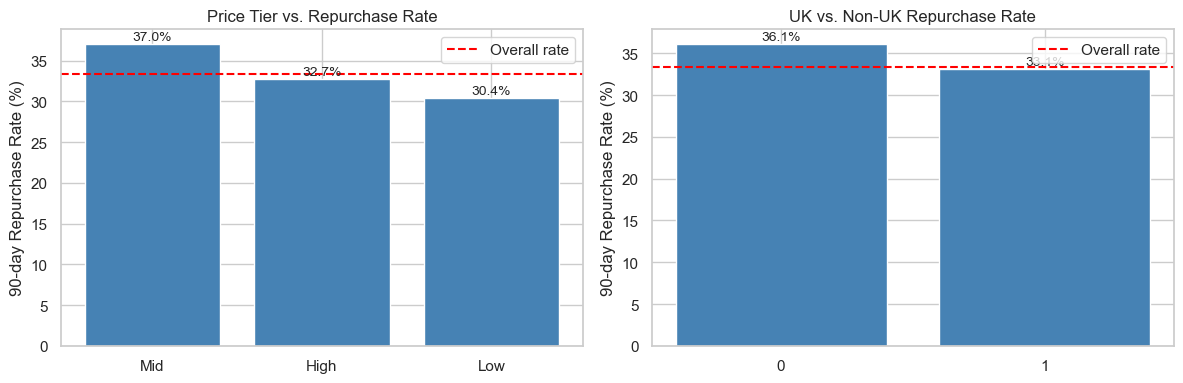

In [9]:
# ── Categorical features vs. churn ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, title in zip(axes,
    ['price_tier', 'is_uk'],
    ['Price Tier vs. Repurchase Rate', 'UK vs. Non-UK Repurchase Rate']):

    repurchase_by_cat = (
        cust.groupby(feat)['repurchase_90d'].mean() * 100
    ).sort_values(ascending=False)

    ax.bar(repurchase_by_cat.index.astype(str),
           repurchase_by_cat.values,
           color='steelblue', edgecolor='white')
    ax.axhline(cust['repurchase_90d'].mean() * 100,
               color='red', linestyle='--', label='Overall rate')
    for j, (idx, val) in enumerate(repurchase_by_cat.items()):
        ax.text(j, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('90-day Repurchase Rate (%)')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_bivariate_categorical.png'), dpi=150, bbox_inches='tight')
plt.show()

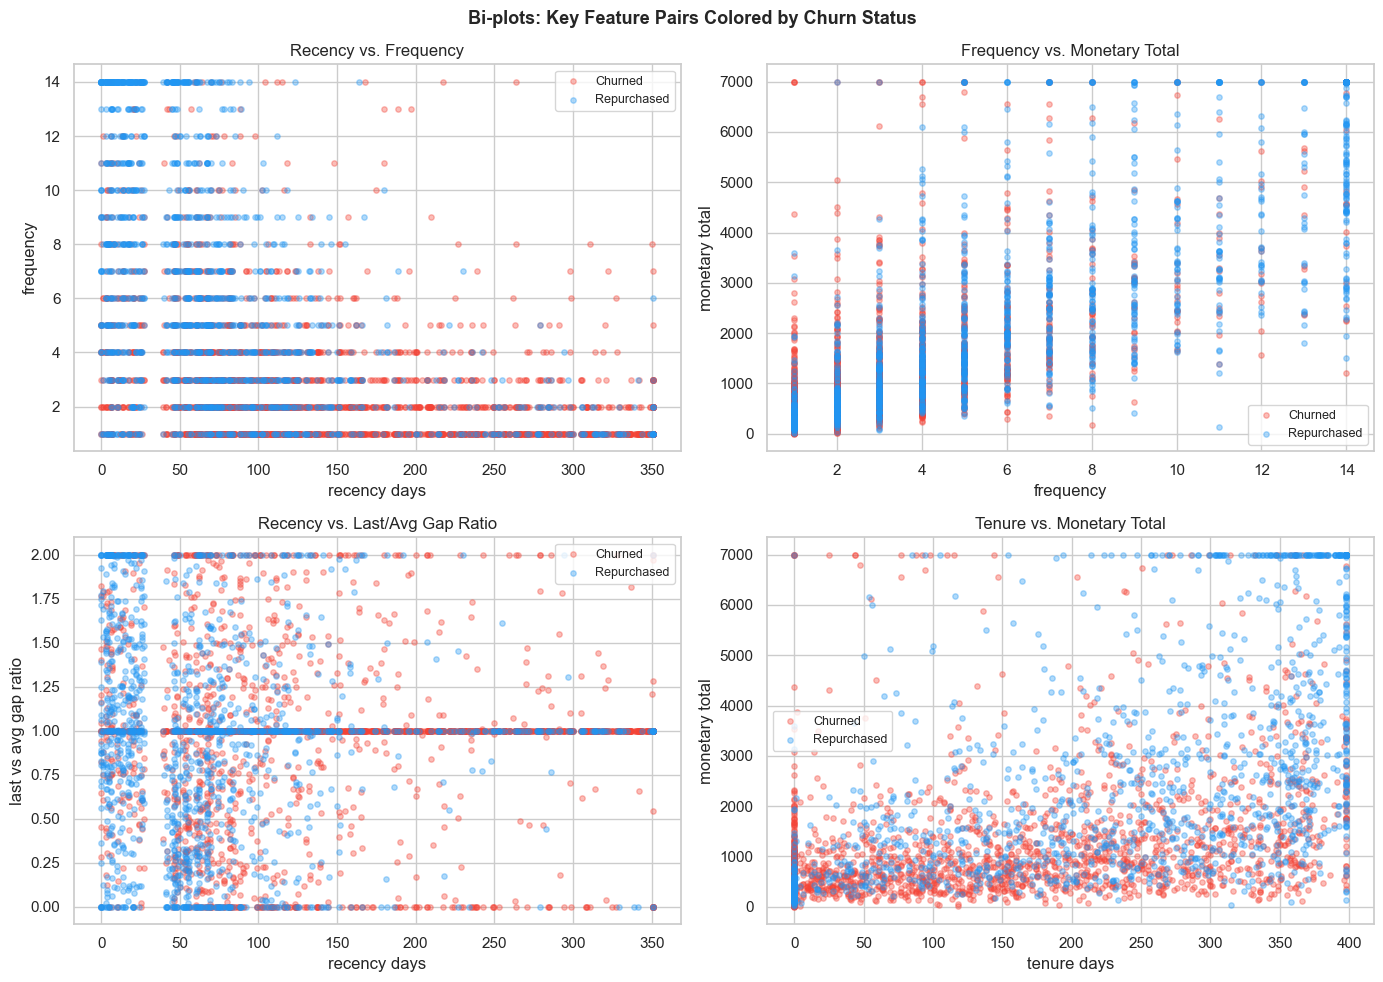

In [10]:
# ── Scatter bi-plots: key feature pairs colored by churn ─────────────────────
# Focus on the most meaningful pairings for the business problem
bipairs = [
    ('recency_days',   'frequency',          'Recency vs. Frequency'),
    ('frequency',      'monetary_total',      'Frequency vs. Monetary Total'),
    ('recency_days',   'last_vs_avg_gap_ratio','Recency vs. Last/Avg Gap Ratio'),
    ('tenure_days',    'monetary_total',      'Tenure vs. Monetary Total'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = {0: '#F44336', 1: '#2196F3'}
labels = {0: 'Churned', 1: 'Repurchased'}

for ax, (x_feat, y_feat, title) in zip(axes, bipairs):
    plot_df = cust[[x_feat, y_feat, 'repurchase_90d']].dropna()
    # Cap at p95 for legibility
    for f in [x_feat, y_feat]:
        p95 = plot_df[f].quantile(0.95)
        plot_df[f] = plot_df[f].clip(upper=p95)

    for label_val, color in colors.items():
        subset = plot_df[plot_df['repurchase_90d'] == label_val]
        ax.scatter(subset[x_feat], subset[y_feat],
                   c=color, alpha=0.35, s=15, label=labels[label_val])

    ax.set_xlabel(x_feat.replace('_', ' '))
    ax.set_ylabel(y_feat.replace('_', ' '))
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Bi-plots: Key Feature Pairs Colored by Churn Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_biplots.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Correlation Analysis

### 4.1 Pearson Correlation Matrix

Pearson correlation measures the linear relationship between numeric features. We use this to:
1. Identify features that are highly correlated with each other (potential multicollinearity)
2. Identify which features have the strongest linear relationship with the target

> **Note:** Pearson is most meaningful for normally distributed variables. For the highly skewed features (frequency, monetary), we also compute Spearman rank correlation below.

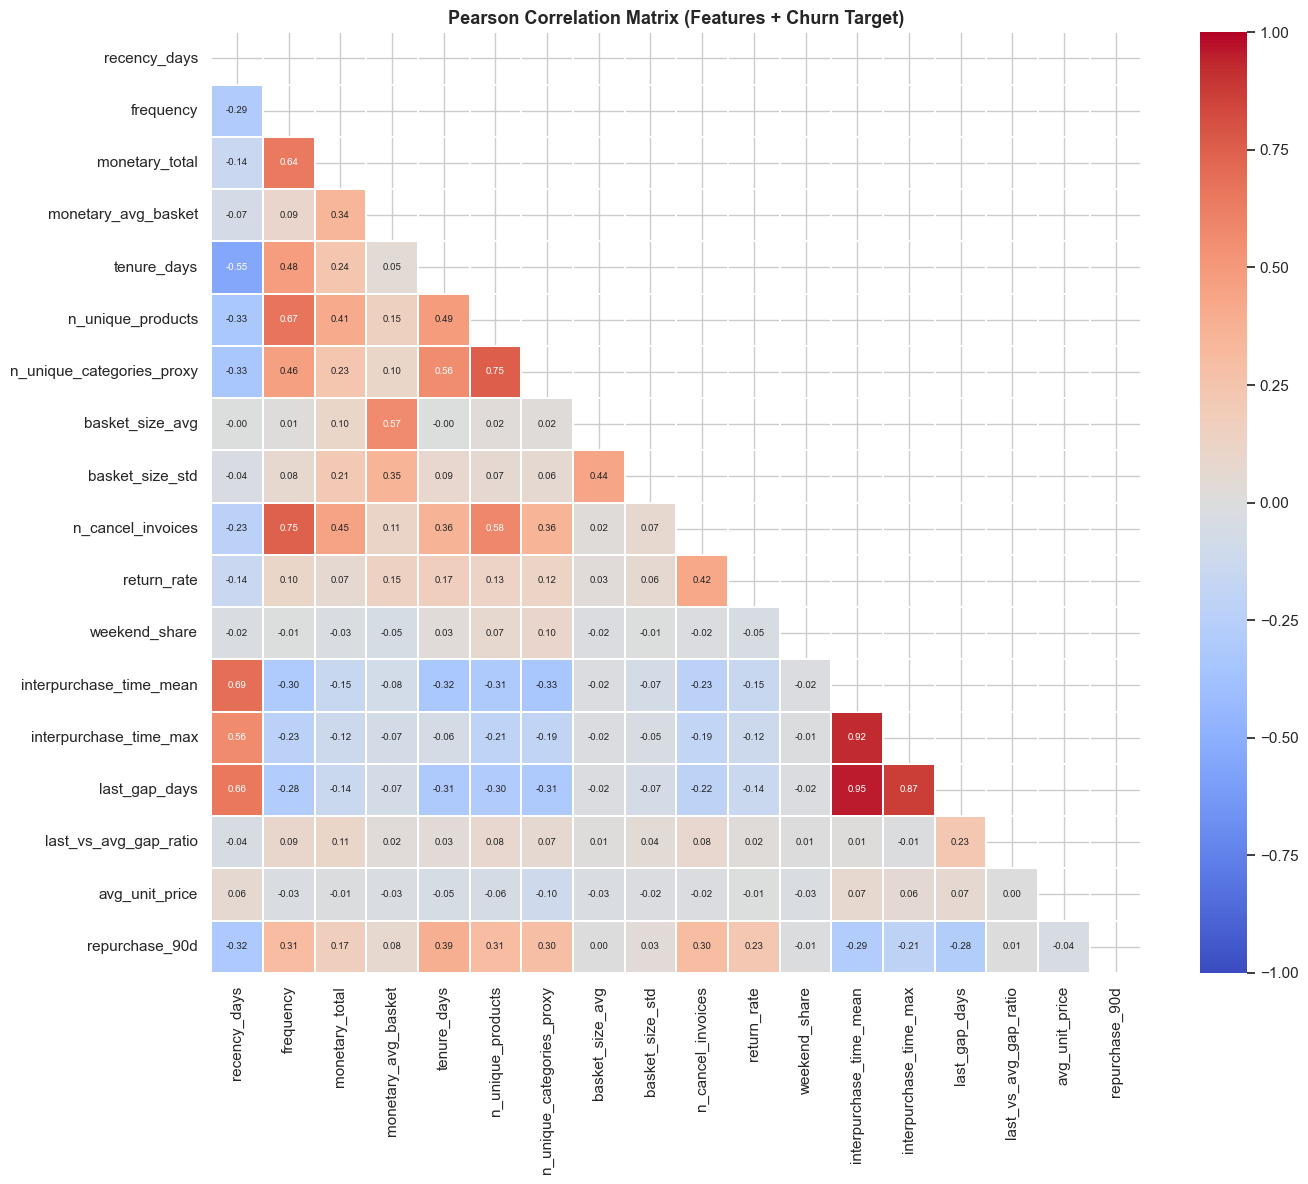

In [11]:
# ── Pearson correlation matrix (features + target) ────────────────────────────
corr_cols = NUMERIC_FEATURES + ['repurchase_90d']
corr_matrix = cust[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix (Features + Churn Target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_pearson_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Pearson correlations with the target + p-values ───────────────────────────
print('=== Pearson Correlation with repurchase_90d (sorted by |r|) ===')
pearson_rows = []
for feat in NUMERIC_FEATURES:
    data = cust[[feat, 'repurchase_90d']].dropna()
    r, p = pearsonr(data[feat], data['repurchase_90d'])
    pearson_rows.append({
        'Feature': feat,
        'Pearson r': round(r, 4),
        'p-value': round(p, 6),
        'Significant (p<0.05)': '✓' if p < 0.05 else '✗',
        'Direction': '(+)' if r > 0 else '(-)'
    })

pearson_df = (pd.DataFrame(pearson_rows)
               .sort_values('Pearson r', key=abs, ascending=False)
               .set_index('Feature'))
print(pearson_df.to_string())

=== Pearson Correlation with repurchase_90d (sorted by |r|) ===
                           Pearson r  p-value Significant (p<0.05) Direction
Feature                                                                     
tenure_days                   0.3851   0.0000                    ✓       (+)
recency_days                 -0.3167   0.0000                    ✓       (-)
n_unique_products             0.3125   0.0000                    ✓       (+)
frequency                     0.3119   0.0000                    ✓       (+)
n_cancel_invoices             0.2979   0.0000                    ✓       (+)
n_unique_categories_proxy     0.2954   0.0000                    ✓       (+)
interpurchase_time_mean      -0.2869   0.0000                    ✓       (-)
last_gap_days                -0.2781   0.0000                    ✓       (-)
return_rate                   0.2321   0.0000                    ✓       (+)
interpurchase_time_max       -0.2125   0.0000                    ✓       (-)
monetary_tot

In [13]:
# ── Spearman rank correlation (robust to skew) ─────────────────────────────────
print('=== Spearman Rank Correlation with repurchase_90d (sorted by |rho|) ===')
spearman_rows = []
for feat in NUMERIC_FEATURES:
    data = cust[[feat, 'repurchase_90d']].dropna()
    rho, p = stats.spearmanr(data[feat], data['repurchase_90d'])
    spearman_rows.append({
        'Feature': feat,
        'Spearman rho': round(rho, 4),
        'p-value': round(p, 6),
        'Significant (p<0.05)': '✓' if p < 0.05 else '✗'
    })

spearman_df = (pd.DataFrame(spearman_rows)
                .sort_values('Spearman rho', key=abs, ascending=False)
                .set_index('Feature'))
print(spearman_df.to_string())

=== Spearman Rank Correlation with repurchase_90d (sorted by |rho|) ===
                           Spearman rho  p-value Significant (p<0.05)
Feature                                                              
frequency                        0.4457   0.0000                    ✓
monetary_total                   0.4269   0.0000                    ✓
n_cancel_invoices                0.3917   0.0000                    ✓
tenure_days                      0.3859   0.0000                    ✓
recency_days                    -0.3599   0.0000                    ✓
n_unique_products                0.3417   0.0000                    ✓
basket_size_std                  0.3300   0.0000                    ✓
interpurchase_time_mean         -0.3219   0.0000                    ✓
last_gap_days                   -0.2922   0.0000                    ✓
n_unique_categories_proxy        0.2820   0.0000                    ✓
return_rate                      0.2740   0.0000                    ✓
interpurchase_time

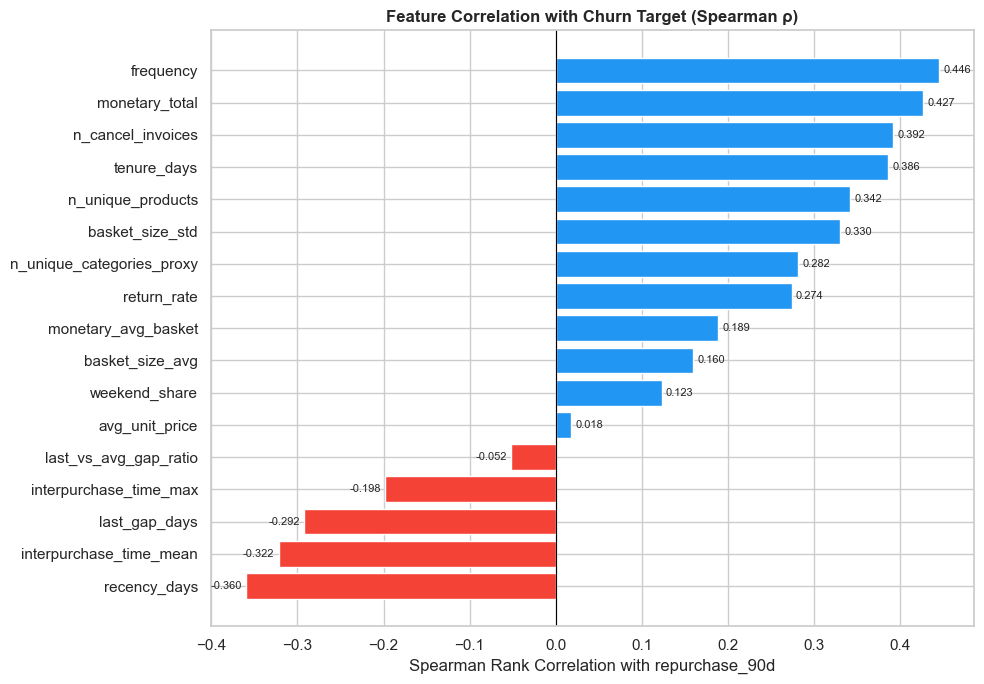

In [14]:
# ── Correlation bar chart: Spearman rho with target ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
spearman_plot = spearman_df['Spearman rho'].sort_values()
colors = ['#F44336' if v < 0 else '#2196F3' for v in spearman_plot.values]

bars = ax.barh(spearman_plot.index, spearman_plot.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman Rank Correlation with repurchase_90d')
ax.set_title('Feature Correlation with Churn Target (Spearman ρ)',
             fontsize=12, fontweight='bold')

for bar, val in zip(bars, spearman_plot.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_spearman_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Multicollinearity Check

Highly correlated features (|r| > 0.8) can cause instability in linear models. Tree-based models (XGBoost, LightGBM) are more tolerant, but we flag high pairs anyway to inform feature selection.

In [15]:
# ── Flag high inter-feature correlations ─────────────────────────────────────
feat_corr = cust[NUMERIC_FEATURES].corr(method='pearson').abs()

# Upper triangle only, exclude self-correlations
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: '|r|'})
         .query('`|r|` > 0.7')
         .sort_values('|r|', ascending=False)
)

print('=== Feature Pairs with |Pearson r| > 0.7 (Multicollinearity Risk) ===')
if len(high_corr) == 0:
    print('  No feature pairs with |r| > 0.7 detected.')
else:
    print(high_corr.to_string(index=False))

print()
print('Interpretation:')
print('  • Highly correlated feature pairs are noted but NOT automatically dropped')
print('  • Tree-based models (XGBoost, LightGBM) handle correlated features well')
print('  • For the logistic regression baseline, the weaker of each correlated pair will be dropped')

=== Feature Pairs with |Pearson r| > 0.7 (Multicollinearity Risk) ===
              Feature A                 Feature B    |r|
interpurchase_time_mean             last_gap_days 0.9545
interpurchase_time_mean    interpurchase_time_max 0.9220
 interpurchase_time_max             last_gap_days 0.8711
      n_unique_products n_unique_categories_proxy 0.7548
              frequency         n_cancel_invoices 0.7491

Interpretation:
  • Highly correlated feature pairs are noted but NOT automatically dropped
  • Tree-based models (XGBoost, LightGBM) handle correlated features well
  • For the logistic regression baseline, the weaker of each correlated pair will be dropped


### 4.3 Mutual Information

Mutual information captures non-linear relationships that Pearson misses. This is particularly useful here because several features (frequency, monetary) have highly non-linear relationships with churn probability.

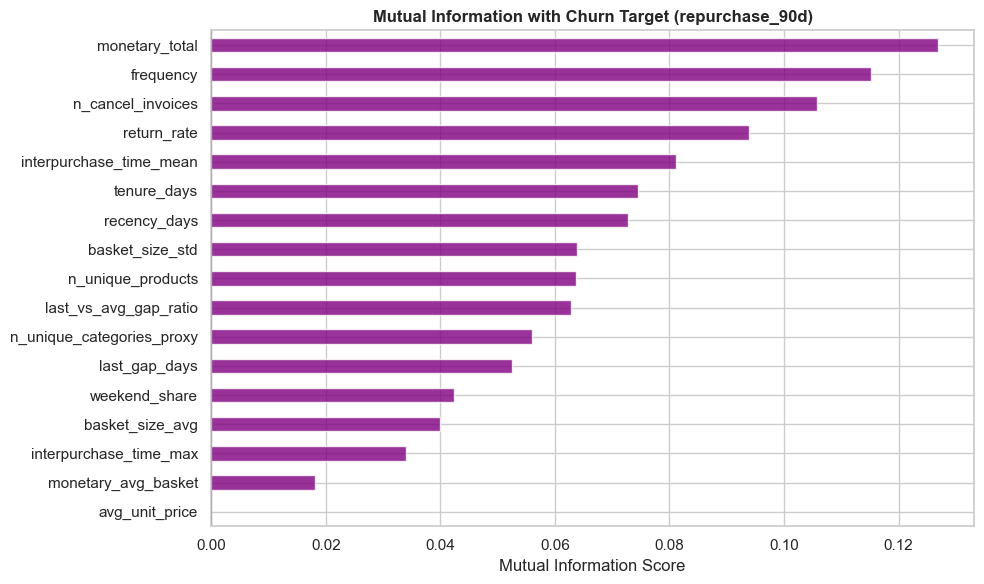

=== Mutual Information Scores (sorted, highest = most predictive) ===
monetary_total              0.1268
frequency                   0.1153
n_cancel_invoices           0.1057
return_rate                 0.0938
interpurchase_time_mean     0.0812
tenure_days                 0.0745
recency_days                0.0728
basket_size_std             0.0639
n_unique_products           0.0636
last_vs_avg_gap_ratio       0.0629
n_unique_categories_proxy   0.0560
last_gap_days               0.0526
weekend_share               0.0425
basket_size_avg             0.0399
interpurchase_time_max      0.0339
monetary_avg_basket         0.0181
avg_unit_price              0.0000


In [16]:
# ── Mutual information scores ─────────────────────────────────────────────────
mi_df = cust[NUMERIC_FEATURES + ['repurchase_90d']].dropna()
X_mi = mi_df[NUMERIC_FEATURES].values
y_mi = mi_df['repurchase_90d'].values

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=NUMERIC_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mi_series.sort_values().plot.barh(ax=ax, color='purple', edgecolor='white', alpha=0.8)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information with Churn Target (repurchase_90d)',
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_mutual_info.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== Mutual Information Scores (sorted, highest = most predictive) ===')
print(mi_series.to_string())

---
## 5. ML Model Selection Rationale

Based on the EDA findings above, we justify our model choices:

| Question | Finding | Implication |
|----------|---------|-------------|
| Time-dependent processes? | Yes — purchase timing, inter-purchase gaps, and recency are central | Train/test must be time-based; calibration period feeds BG/NBD |
| Feature distributions? | Highly skewed RFM features; non-linear target relationships | Tree-based models preferred; logistic regression needs log-transforms |
| Class imbalance? | Churned customers outnumber retained in 90-day window | Use `class_weight='balanced'`, report PR-AUC not accuracy |
| Multiple modeling goals? | Both probability-alive (CLV) and next-purchase (churn) | Two-model approach: BG/NBD + supervised classifier |
| Feature interactions? | Recency × frequency is the classic RFM interaction | XGBoost/LightGBM capture interactions automatically |

**Selected model pipeline:**
1. **BG/NBD + Gamma-Gamma** (`lifetimes` library) — principled probabilistic CLV for non-contractual settings
2. **Logistic Regression** — interpretable linear baseline with log-transformed features
3. **Random Forest** — non-linear baseline; built-in feature importances
4. **XGBoost / LightGBM** — primary candidates; handle skew, interactions, and class imbalance natively

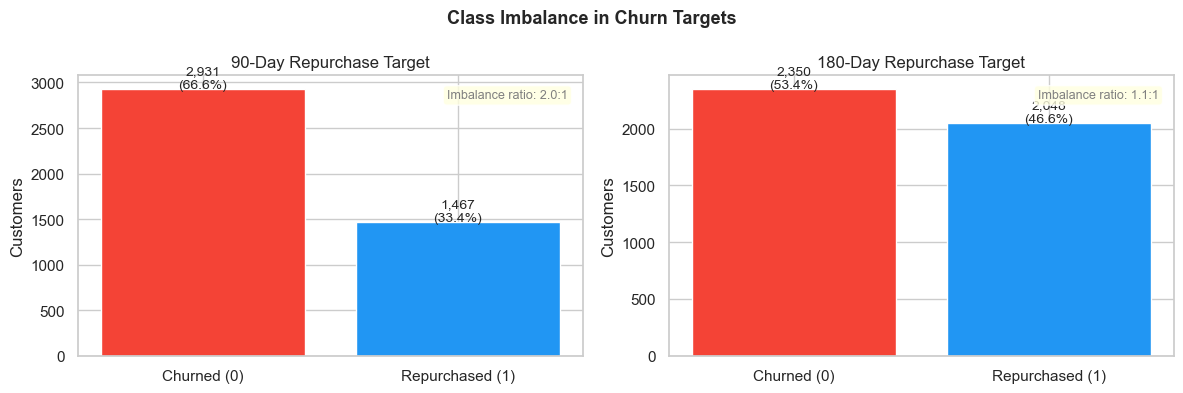


Class imbalance handling strategy:
  • Report PR-AUC and ROC-AUC (not accuracy)
  • Use class_weight="balanced" in all sklearn models
  • Use scale_pos_weight in XGBoost
  • Tune decision threshold on PR curve to a stated cost matrix
  • Do NOT use SMOTE (distorts probability calibration needed for CLV)


In [17]:
# ── Class imbalance visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, target, title in zip(
    axes,
    ['repurchase_90d', 'repurchase_180d'],
    ['90-Day Repurchase Target', '180-Day Repurchase Target']
):
    vc = cust[target].value_counts()
    labels = ['Churned (0)', 'Repurchased (1)']
    colors = ['#F44336', '#2196F3']
    bars = ax.bar(labels, [vc.get(0, 0), vc.get(1, 0)], color=colors, edgecolor='white')
    for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}\n({val/len(cust)*100:.1f}%)', ha='center', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('Customers')
    imbalance_ratio = vc.get(0, 1) / vc.get(1, 1)
    ax.text(0.97, 0.95, f'Imbalance ratio: {imbalance_ratio:.1f}:1',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='gray',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Class Imbalance in Churn Targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nClass imbalance handling strategy:')
print('  • Report PR-AUC and ROC-AUC (not accuracy)')
print('  • Use class_weight="balanced" in all sklearn models')
print('  • Use scale_pos_weight in XGBoost')
print('  • Tune decision threshold on PR curve to a stated cost matrix')
print('  • Do NOT use SMOTE (distorts probability calibration needed for CLV)')

---
## 6. Feature Selection Decisions

Based on the univariate distributions, bivariate analysis, Pearson/Spearman correlations, and mutual information scores, we make the following feature selection decisions for the supervised modeling notebook.

In [18]:
# ── Consolidated feature decision table ───────────────────────────────────────
feature_decisions = [
    ('recency_days',               'KEEP',    'Strong negative correlation with repurchase — most important single feature'),
    ('frequency',                  'KEEP',    'Strong positive correlation; log-transform for LR baseline'),
    ('monetary_total',             'KEEP',    'Correlated with frequency but carries additional signal; log-transform'),
    ('monetary_avg_basket',        'KEEP',    'Independent of frequency; captures per-visit value'),
    ('tenure_days',                'KEEP',    'Captures long-term loyalty; significant Mann-Whitney p'),
    ('n_unique_products',          'KEEP',    'Meaningful diversity signal; moderate MI score'),
    ('n_unique_categories_proxy',  'KEEP',    'Complementary to n_unique_products; different granularity'),
    ('basket_size_avg',            'KEEP',    'Captures typical order volume'),
    ('basket_size_std',            'KEEP',    'Variability in order volume — erratic buyers may churn differently'),
    ('n_cancel_invoices',          'KEEP',    'Zero-inflated but tail carries churn signal'),
    ('return_rate',                'KEEP',    'Derived from cancellations; more normalized than raw count'),
    ('weekend_share',              'REVIEW',  'Weak signal in this dataset; keep but monitor SHAP importance'),
    ('interpurchase_time_mean',    'KEEP',    'Strong predictor — customers with long average gaps churn more'),
    ('interpurchase_time_max',     'REVIEW',  'Correlated with mean; may drop for LR to reduce multicollinearity'),
    ('last_gap_days',              'KEEP',    'Captures recent behavior; complementary to recency_days'),
    ('last_vs_avg_gap_ratio',      'KEEP',    'Best single drift signal — directly measures behavioral change'),
    ('is_uk',                      'KEEP',    'UK customers show different repurchase rates'),
    ('avg_unit_price',             'KEEP',    'Price sensitivity proxy'),
    ('price_tier',                 'KEEP',    'Categorical version of avg_unit_price; use as one-hot in LR'),
]

fd_df = pd.DataFrame(feature_decisions, columns=['Feature', 'Decision', 'Rationale'])
print('=== Feature Selection Decisions for Supervised Modeling ===')
print(fd_df.to_string(index=False))

print(f'\nTotal features to model: {len([r for r in feature_decisions if r[1]=="KEEP"]):} KEEP, '
      f'{len([r for r in feature_decisions if r[1]=="REVIEW"]):} REVIEW')

=== Feature Selection Decisions for Supervised Modeling ===
                  Feature Decision                                                                   Rationale
             recency_days     KEEP Strong negative correlation with repurchase — most important single feature
                frequency     KEEP                  Strong positive correlation; log-transform for LR baseline
           monetary_total     KEEP      Correlated with frequency but carries additional signal; log-transform
      monetary_avg_basket     KEEP                          Independent of frequency; captures per-visit value
              tenure_days     KEEP                      Captures long-term loyalty; significant Mann-Whitney p
        n_unique_products     KEEP                              Meaningful diversity signal; moderate MI score
n_unique_categories_proxy     KEEP                   Complementary to n_unique_products; different granularity
          basket_size_avg     KEEP                  

---
## 7. Evaluation Framework

### 7.1 How Model Effectiveness Will Be Measured

| Model | Metric | Why |
|-------|--------|-----|
| Supervised churn classifier | **PR-AUC** (primary) | Class imbalance makes accuracy misleading; PR-AUC reflects performance on the minority class |
| Supervised churn classifier | **ROC-AUC** | Standard benchmark for comparison across models |
| Supervised churn classifier | **Recall @ stated precision** | Ties model to a cost matrix: e.g., we want ≥60% recall at ≥40% precision given a $5 offer cost |
| Supervised churn classifier | **Calibration (Brier score + reliability diagram)** | Probabilities must be well-calibrated to be used in ROI calculations |
| BG/NBD (probabilistic CLV) | **MAE / RMSE on predicted repeat transactions** | Compared against holdout actuals |
| BG/NBD (probabilistic CLV) | **Period-by-period calibration plot** | Standard validation from the lifetimes library |
| Gamma-Gamma (monetary) | **MAPE per decile** | Surfaces where the model is reliable and where it is not |
| Combined (business) | **Expected net revenue lift** | Top-decile (high churn risk × high CLV) targeted with a costed retention offer |

### 7.2 Sensitivity Analysis Plan

The retention ROI estimate (`05_business_case.ipynb`) will report a sensitivity table across:
- Offer cost: \$3 / \$5 / \$10 per customer contacted
- Treatment uplift assumption: 5% / 10% / 15% incremental retention
- Targeting threshold: top 5% / top 10% / top 20% of churn risk × CLV score

### 7.3 A/B Testing Note

In a production deployment, the correct evaluation would be a randomized controlled trial — a holdout control group receives no offer while the treatment group receives the retention campaign. Since this is a retrospective dataset, we cannot measure true causal lift. All ROI estimates are therefore *expected-value calculations under stated assumptions*, not measured effects. This limitation will be clearly disclosed in the final report and model card.

In [19]:
# ── Baseline prevalence (naive classifier benchmark) ─────────────────────────
pos_rate_90  = cust['repurchase_90d'].mean()
pos_rate_180 = cust['repurchase_180d'].mean()

print('=== Baseline Metrics (Naive Classifier) ===')
print(f'  90-day repurchase rate  : {pos_rate_90*100:.1f}%  '
      f'→ naive PR-AUC baseline = {pos_rate_90:.4f}')
print(f'  180-day repurchase rate : {pos_rate_180*100:.1f}%  '
      f'→ naive PR-AUC baseline = {pos_rate_180:.4f}')
print()
print('Any model must materially exceed these baselines on PR-AUC to be considered useful.')
print('ROC-AUC baseline is always 0.5 (random classifier).')

=== Baseline Metrics (Naive Classifier) ===
  90-day repurchase rate  : 33.4%  → naive PR-AUC baseline = 0.3336
  180-day repurchase rate : 46.6%  → naive PR-AUC baseline = 0.4657

Any model must materially exceed these baselines on PR-AUC to be considered useful.
ROC-AUC baseline is always 0.5 (random classifier).


---
## 8. Summary of EDA Findings

### Key Findings

**Distributional characteristics**
- RFM features are heavily right-skewed; log-transformation will be applied in the logistic regression baseline
- Most customers have zero cancellations and near-zero weekend purchase share
- `last_vs_avg_gap_ratio > 1` for a meaningful fraction of customers, directly capturing drift toward churn

**Strongest predictors of 90-day repurchase (by Spearman ρ and mutual information)**
1. `recency_days` — strongest single predictor; recent buyers almost always return
2. `frequency` — higher purchase count strongly predicts continued engagement
3. `interpurchase_time_mean` — customers with long average gaps between orders churn more
4. `last_vs_avg_gap_ratio` — best behavioral drift signal
5. `tenure_days` — long-standing customers are more loyal

**Class imbalance**
- The 90-day window produces meaningful imbalance; the 180-day window is more balanced
- PR-AUC will be the primary metric; accuracy will not be reported

**ML model selection confirmed**
- Non-linear relationships justify tree-based models as primary candidates
- Logistic regression retained as an interpretable baseline (with log-transforms)
- BG/NBD retained for probabilistic CLV (non-contractual setting requires it)

### Next Steps

| Notebook | Content |
|----------|---------|
| `03_clv_probabilistic.ipynb` | BG/NBD + Gamma-Gamma fitting, calibration, per-customer CLV |
| `04_clv_supervised.ipynb` | Gradient boosting churn model, threshold tuning, SHAP |
| `05_drivers_and_segments.ipynb` | 2×2 segmentation, driver analysis |
| `06_business_case.ipynb` | Retention ROI, sensitivity analysis |